In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('career_recommender.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?
0,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85
1,B.E,Computer Science Engineering,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",66.5
2,BA,Psychology,Understand human behaviour,People management;Communication skills,64.6
3,MBA,Commerce,Sales/Marketing;Trading;Understand human behav...,Accounting Skills;Critical Thinking,75.525
4,B.Tech,Instrumentation Engineering,Technology,\nPLC Allen Bradley;PLC Ladder Logic;LabVIEW;B...,70.68


In [3]:
df.shape

(1195, 5)

In [4]:
print(df.shape)
df.info()

(1195, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 5 columns):
 #   Column                                                                 Non-Null Count  Dtype 
---  ------                                                                 --------------  ----- 
 0   What was your course in UG?                                            1195 non-null   object
 1   What is your UG specialization? Major Subject (Eg; Mathematics)        1195 non-null   object
 2   What are your interests?                                               1195 non-null   object
 3   What are your skills ? (Select multiple if necessary)                  1194 non-null   object
 4   What was the average CGPA or Percentage obtained in under graduation?  1195 non-null   object
dtypes: object(5)
memory usage: 46.8+ KB


In [5]:
cat_cols = [
    "What was your course in UG?",
    "What is your UG specialization? Major Subject (Eg; Mathematics)",
    "What are your interests?",
    "What are your skills ? (Select multiple if necessary)"
]


In [6]:
df[cat_cols] = df[cat_cols].fillna("Unknown")


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_encoded = encoder.fit_transform(df[cat_cols])


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)


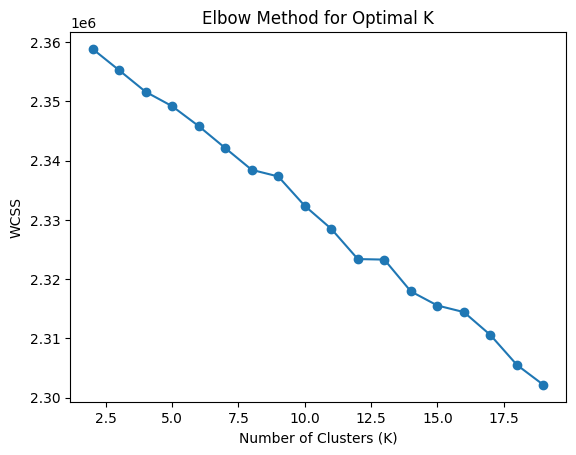

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 20), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


In [10]:
kmeans = KMeans(n_clusters=6, init="k-means++", n_init=20, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [11]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=6, linkage="ward")
df["Hierarchical_Cluster"] = hier.fit_predict(X_scaled)


In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]


In [14]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="KMeans_Cluster",
    title="K-Means Clustering (3D PCA Space)"
)
fig.show()



In [15]:
fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Hierarchical_Cluster",
    title="Hierarchical Clustering (3D PCA Space)"
)
fig.show()


In [16]:
fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="DBSCAN_Cluster",
    title="DBSCAN Clustering (3D PCA Space)"
)
fig.show()


In [17]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=3, random_state=42)
X_final = svd.fit_transform(X_encoded)

In [18]:
X_final.shape   # should be (rows, 2)

(1195, 3)

In [19]:
X_final

array([[ 0.04357115,  0.17206773,  0.5509951 ],
       [ 0.45452958,  0.48232057,  0.86591318],
       [ 0.00579326,  0.01213321,  0.01765167],
       ...,
       [ 0.92161518, -0.21100828, -0.16728123],
       [ 0.04809418,  0.86302753, -0.32259798],
       [ 0.02927425,  0.1733101 ,  0.54950142]], shape=(1195, 3))

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=9, n_init=30, random_state=42)
labels = kmeans.fit_predict(X_final)

print("Final Silhouette:", silhouette_score(X_final, labels))



Final Silhouette: 0.7301256790718723


In [21]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# Dimensionality reduction (BEST FOUND)
svd = TruncatedSVD(n_components=5, random_state=42)
X_final = svd.fit_transform(X_encoded)

# KMeans clustering (use best K you selected, e.g., 9)
kmeans = KMeans(n_clusters=9, n_init=30, random_state=42)
df["Final_Cluster"] = kmeans.fit_predict(X_final)



In [22]:
df["SVD1"] = X_final[:, 0]
df["SVD2"] = X_final[:, 1]
df["SVD3"] = X_final[:, 2]



In [23]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="SVD1",
    y="SVD2",
    z="SVD3",
    color="Final_Cluster",
    title="3D Visualization of Student Clusters (TruncatedSVD + KMeans)",
    labels={
        "SVD1": "Latent Component 1",
        "SVD2": "Latent Component 2",
        "SVD3": "Latent Component 3",
        "Final_Cluster": "Cluster"
    }
)

fig.show()


In [ ]:
centers = kmeans.cluster_centers_

fig = px.scatter_3d(
    df,
    x="SVD1",
    y="SVD2",
    z="SVD3",
    color="Final_Cluster",
    title="3D Clusters with Centroids"
)

fig.add_scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode="markers",
    marker=dict(size=8),
    name="Centroids"
)

fig.show()

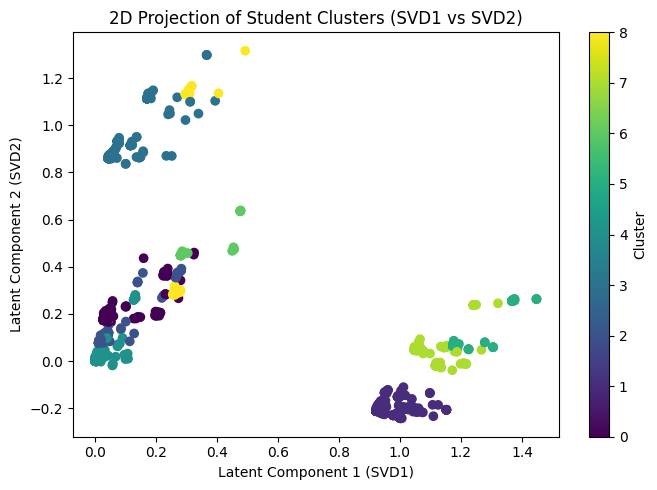

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    df["SVD1"],
    df["SVD2"],
    c=df["Final_Cluster"]
)
plt.xlabel("Latent Component 1 (SVD1)")
plt.ylabel("Latent Component 2 (SVD2)")
plt.title("2D Projection of Student Clusters (SVD1 vs SVD2)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


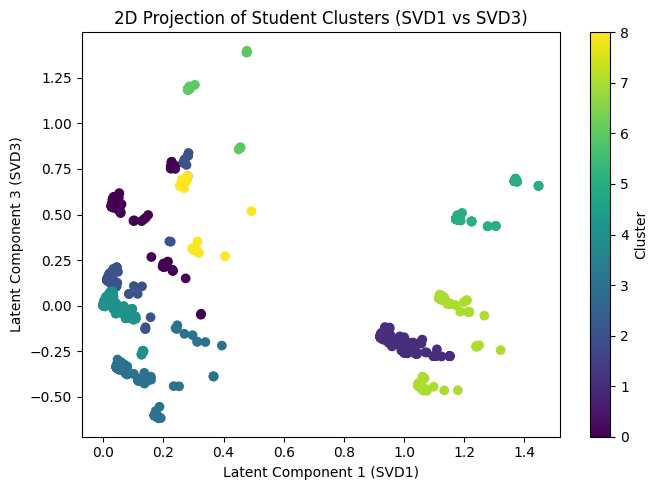

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["SVD1"],
    df["SVD3"],
    c=df["Final_Cluster"]
)
plt.xlabel("Latent Component 1 (SVD1)")
plt.ylabel("Latent Component 3 (SVD3)")
plt.title("2D Projection of Student Clusters (SVD1 vs SVD3)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


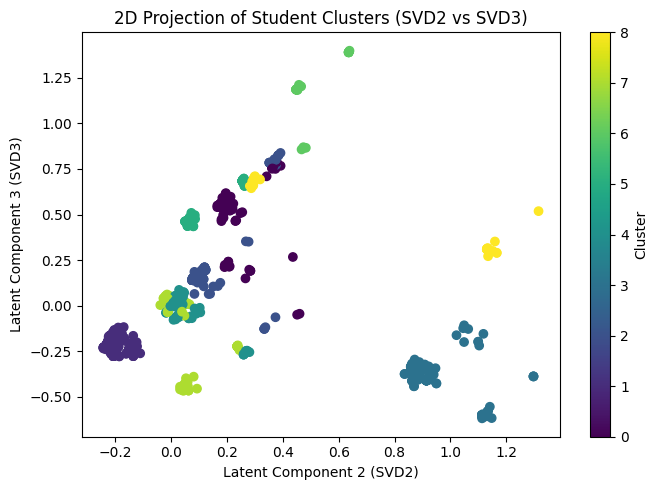

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["SVD2"],
    df["SVD3"],
    c=df["Final_Cluster"]
)
plt.xlabel("Latent Component 2 (SVD2)")
plt.ylabel("Latent Component 3 (SVD3)")
plt.title("2D Projection of Student Clusters (SVD2 vs SVD3)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


In [28]:
# Save results for the Meta-Model
df.to_csv('career_results.csv', index=False)
print("Career results exported to career_results.csv")

Career results exported to career_results.csv


In [ ]:
import pickle
with open('career_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)